In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

sns.set(context='talk')
%matplotlib widget

### load

In [2]:
pca_df      = pd.read_csv('../../results/pca_df.csv')
beh_df      = pd.read_csv('../../results/beh_df.csv')
hidden_stack = np.load('../../results/hidden_stack.npy')  # (n_nets, 60, 10)

boundaries = tuple(sorted(pca_df['boundary'].unique()))  # (0.25, 0.5, 0.75)

In [3]:
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.047619,0,0,0.0,-0.343129,-0.006083,0.023421
1,0.25,b=0.25,0.047619,1,0,0.0,-0.343129,-0.006083,0.023421
2,0.25,b=0.25,0.095238,2,1,0.0,-0.328170,-0.001651,0.013417
3,0.25,b=0.25,0.095238,3,1,0.0,-0.328171,-0.001652,0.013417
4,0.25,b=0.25,0.142857,4,2,0.0,-0.306723,0.002879,0.007066


In [4]:
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned,stim_rank
0,0.25,b=0.25,0.047619,0,0,0.0,0.169804,0.0,0,-0.202381,-0.080196,1.5
1,0.25,b=0.25,0.047619,1,0,0.0,0.169804,0.0,0,-0.202381,-0.080196,1.5
2,0.25,b=0.25,0.095238,2,1,0.0,0.182941,0.0,0,-0.154762,-0.067059,3.5
3,0.25,b=0.25,0.095238,3,1,0.0,0.182941,0.0,0,-0.154762,-0.067059,3.5
4,0.25,b=0.25,0.142857,4,2,0.0,0.196852,0.0,0,-0.107143,-0.053148,5.5


In [5]:
hidden_stack.shape

(30, 60, 10)

### PCA

In [6]:

# plots 4-6: same as plots 1-3 but with a single shared viridis colormap
# so that the same stimulus position maps to the same color across conditions
shared_cmap = plt.cm.viridis

# legend: swatch at the boundary value on the global stim scale
legend_handles_shared = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=shared_cmap(shared_norm(bound)), markersize=10,
           label=f'b={bound:.2f}')
    for bound in boundaries
]

# plot 4: raw PCA, shared viridis
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')
for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9)
ax.set_title('Hidden units projected to PCA (shared viridis)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')
plt.tight_layout()
plt.show()

# plot 5: PC-centroid-subtracted, shared viridis
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')
for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9)
ax.set_title('PC-centroid-subtracted PCA (shared viridis)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')
plt.tight_layout()
plt.show()

# plot 6: hidden-centroid-subtracted, shared viridis
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')
for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_c'], cond_df['PC2_c'], cond_df['PC3_c'], c=colors, s=55, alpha=0.9)
ax.set_title('Hidden-centroid-subtracted PCA (shared viridis)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')
plt.tight_layout()
plt.show()


NameError: name 'Line2D' is not defined

interpretations:
1. context separation along boundary shift
2. same stim differs across conditions; suggests relative coding
3. stimulus separation over compressed region, reflecting...? make sure this is not a response artifact. I think you're good!

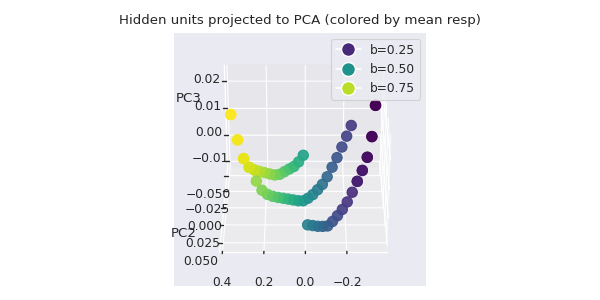

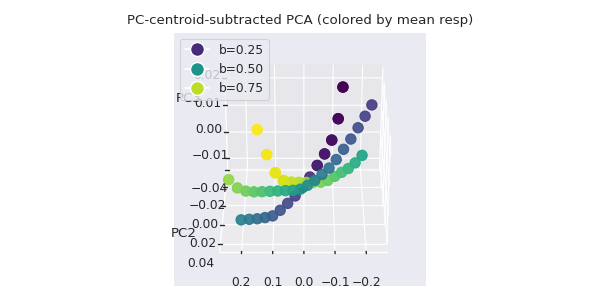

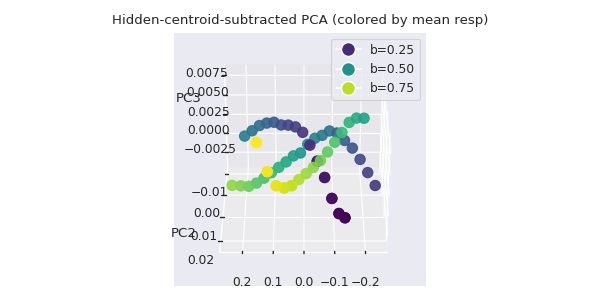

In [ ]:

# merge mean resp (averaged across networks) into pca_df
mean_resp = beh_df.groupby(['boundary', 'stim'])['resp'].mean().reset_index()
pca_df = pca_df.merge(mean_resp, on=['boundary', 'stim'], how='left')

shared_cmap = plt.cm.viridis
shared_norm_resp = Normalize(vmin=pca_df['resp'].min(), vmax=pca_df['resp'].max())

legend_handles_resp = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=shared_cmap(shared_norm_resp(b)), markersize=10,
           label=f'b={b:.2f}')
    for b in boundaries
]

# plot 7: raw PCA, colored by mean resp
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')
for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('resp')
    colors = shared_cmap(shared_norm_resp(cond_df['resp'].values))
    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9)
ax.set_title('Hidden units projected to PCA (colored by mean resp)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_resp, loc='best')
plt.tight_layout(); plt.show()

# plot 8: PC-centroid-subtracted, colored by mean resp
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')
for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('resp')
    colors = shared_cmap(shared_norm_resp(cond_df['resp'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9)
ax.set_title('PC-centroid-subtracted PCA (colored by mean resp)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_resp, loc='best')
plt.tight_layout(); plt.show()

# plot 9: hidden-centroid-subtracted, colored by mean resp
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')
for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('resp')
    colors = shared_cmap(shared_norm_resp(cond_df['resp'].values))
    ax.scatter(cond_df['PC1_c'], cond_df['PC2_c'], cond_df['PC3_c'], c=colors, s=55, alpha=0.9)
ax.set_title('Hidden-centroid-subtracted PCA (colored by mean resp)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_resp, loc='best')
plt.tight_layout(); plt.show()


## single-unit

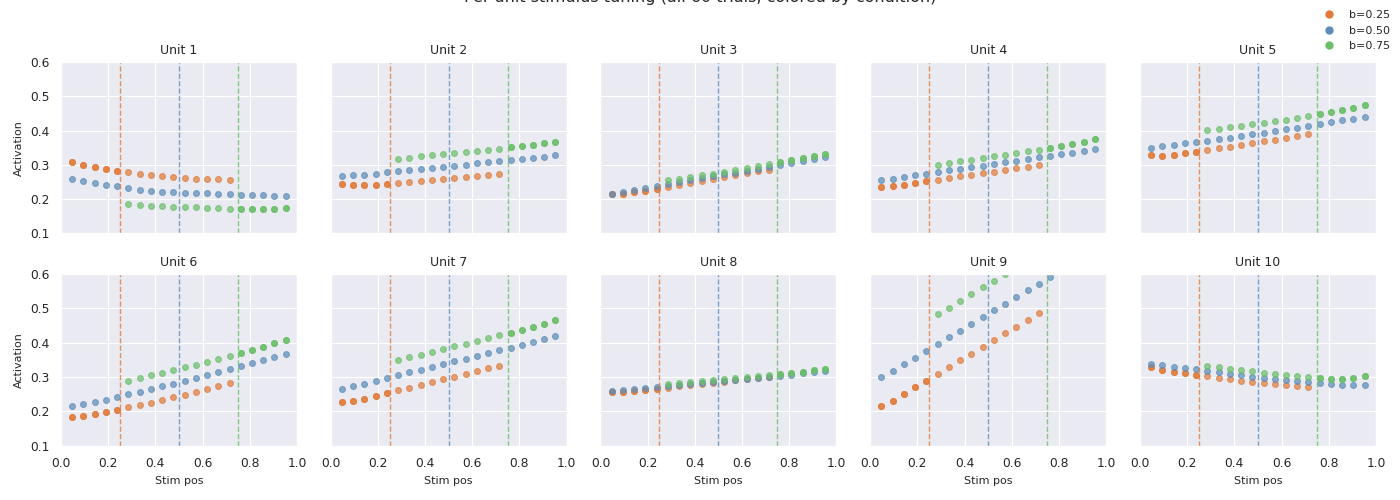

In [ ]:
# build tuning_df
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]
n_units = hidden_mean.shape[1]
cond_colors = {0.25: '#e07b39', 0.50: '#5b8db8', 0.75: '#6abf69'}

tuning_df = pca_df[['boundary', 'stim']].copy().reset_index(drop=True)
for i in range(n_units):
    tuning_df[f'unit_{i}'] = hidden_mean[:, i]

# 5×2 per-unit grid
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    for bound in boundaries:
        cond_df = tuning_df[tuning_df['boundary'] == bound].sort_values('stim')
        ax.scatter(cond_df['stim'], cond_df[f'unit_{i}'],
                   color=cond_colors[bound], s=18, alpha=0.7)
        ax.axvline(bound, color=cond_colors[bound], linestyle='--', linewidth=1, alpha=0.8)
    ax.set_title(f'Unit {i+1}', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.1, 0.6)
    if i % 5 == 0:
        ax.set_ylabel('Activation', fontsize=8)
    if i >= 5:
        ax.set_xlabel('Stim pos', fontsize=8)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cond_colors[b],
               markersize=7, label=f'b={b:.2f}')
    for b in boundaries
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=8, frameon=False,
           bbox_to_anchor=(1.0, 1.0))
plt.suptitle('Per-unit stimulus tuning (all 60 trials, colored by condition)', y=1.02)
plt.tight_layout()
plt.show()

### population

questions to ask yourself:
1. what is population analysis buying you that single-neuron doesn't?
2. what is special about your setup compared to ramon's preprint? Yes, contexts are probably, unsurprisingly, going to be ordered. But perhaps, there is some asymmetry of the 2 compressed contexts w.r.t baseline? A sort of hierarchical arragnement of contexts, where axis 1 reads out ordering, while axis 2 reads is the reflection line for compressed contexts? More realistically, there is only going to be one axis, unless the brain really cares about baseline vs not.. and if there is axis 2, it would support the mixed-selectivity, non-linearity hypothesis.